In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline # Crucial: Use imblearn's pipeline, not sklearn's, to handle SMOTE properly
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


# **Preparing and Cleaning The Dataset**

In [9]:
columns = ["Age","Sex","ChestPainType", "RestingBP","Cholesterol","FastingBS","RestingECG","MaxHR","ExerciseAngina","Oldpeak","ST_Slope","HeartDisease"]
df = pd.read_csv("heart.csv", names=columns, header=0)

# Handle zero values based on median
df["Cholesterol"] = df["Cholesterol"].replace(0, df["Cholesterol"].median())
df["RestingBP"] = df["RestingBP"].replace(0, df["RestingBP"].median())

# Removing rows with missing values
df = df.dropna(subset=["Age","Sex","ChestPainType", "RestingBP","Cholesterol","FastingBS","RestingECG","MaxHR","ExerciseAngina","Oldpeak","ST_Slope","HeartDisease"])

# Encoding Categorical columns
cat_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=cat_columns, drop_first=False)

print("Dataframe shape : ",df_encoded.shape)


Dataframe shape :  (918, 21)


# **Data Splitting**
We split the data first. All scaling and SMOTE will happen inside the cross-validation pipeline to prevent data leakage.

In [10]:
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Distribution:", Counter(y_train))
print("Testing Distribution:", Counter(y_test))

Training Distribution: Counter({1: 406, 0: 328})
Testing Distribution: Counter({1: 102, 0: 82})


# **Robust Optimization: Pipeline + Stratified K-Fold + GridSearchCV**
By putting MinMaxScaler, SMOTE, and MultinomialNB into a Pipeline, we ensure that during cross-validation, synthetic data is only generated on the *training* fold and never bleeds into the *validation* fold.

In [11]:
# Define the pipeline steps
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('smote', SMOTE(random_state=42)),
    ('mnb', MultinomialNB())
])

# Define the parameters to tune (note the prefix matching the pipeline step name)
param_grid = {
    'smote__k_neighbors': [3, 5, 7],           # Tuning SMOTE behavior
    'mnb__alpha': [0.01, 0.1, 0.5, 1.0, 5.0],  # Tuning Naive Bayes smoothing
    'mnb__fit_prior': [True, False]
}

# Define Stratified K-Fold to maintain class balance in all folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the rigorous pipeline
grid_search.fit(X_train, y_train)

print("Best Parameters Found: ", grid_search.best_params_)
print("Best Strict Cross-Validation Accuracy: {:.4f}".format(grid_search.best_score_))

# Extract the best pipeline model
best_pipeline = grid_search.best_estimator_

Best Parameters Found:  {'mnb__alpha': 5.0, 'mnb__fit_prior': True, 'smote__k_neighbors': 7}
Best Strict Cross-Validation Accuracy: 0.8515


# **Final Model Evaluation on Test Set**

In [ ]:
# Make predictions. The pipeline automatically applies the scaler to X_test.
y_pred = best_pipeline.predict(X_test)

print("Test Accuracy : {:.4f}".format(accuracy_score(y_test, y_pred)))
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_pred))

Test Accu : 0.8533

Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84        82
           1       0.89      0.84      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184



# **Confusion Matrix**

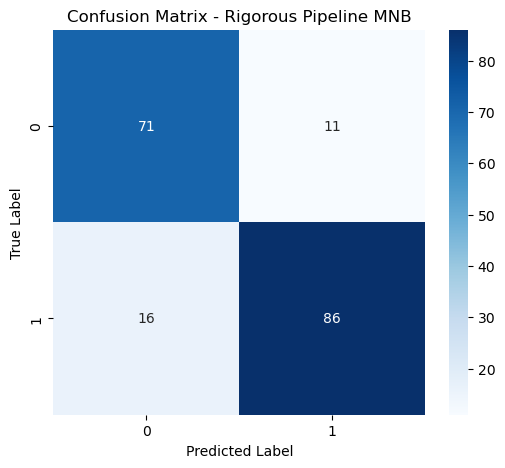

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Rigorous Pipeline MNB')
plt.show()

# **Training and Validation Accuracy (Learning Curve)**

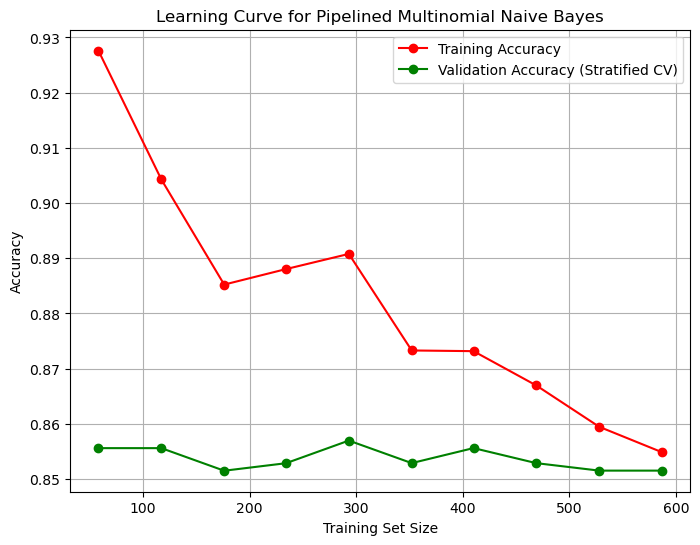

In [14]:
# Pass the entire rigorous pipeline to the learning curve
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=best_pipeline,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1
)

train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label="Training Accuracy")
plt.plot(train_sizes, validation_scores_mean, 'o-', color='g', label="Validation Accuracy (Stratified CV)")
plt.title("Learning Curve for Pipelined Multinomial Naive Bayes")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()
